In [1]:
from google.colab import files
uploaded = files.upload()

Saving vdp_clean_noisy_trajectory.csv to vdp_clean_noisy_trajectory.csv


In [2]:
import pandas as pd
from pathlib import Path
import shutil

BASE_DIR = Path("/content/hybrid_neural_sindy")
DATA_DIR = BASE_DIR / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

uploaded_filename = list(uploaded.keys())[0]

source_path = Path("/content") / uploaded_filename
target_path = DATA_DIR / "vdp_clean_noisy_trajectory.csv"

shutil.move(str(source_path), str(target_path))

vdp_df = pd.read_csv(target_path)

print("Dataset loaded successfully.")
print("Saved at:", target_path)
print("Shape:", vdp_df.shape)

vdp_df.head()

Dataset loaded successfully.
Saved at: /content/hybrid_neural_sindy/data/vdp_clean_noisy_trajectory.csv
Shape: (3000, 5)


,t,x_clean,y_clean,x_noisy,y_noisy
0,0.000000,2.000000,0.000000,2.045708,-0.155998
1,0.010003,1.999902,-0.019418,2.112470,0.121667
2,0.020007,1.999615,-0.037703,1.706960,-0.233030
3,0.030010,1.999151,-0.054921,2.018327,-0.102358
4,0.040013,1.998520,-0.071135,1.996000,-0.199091


In [3]:
import numpy as np
# Extract columns from dataframe
t = vdp_df["t"].values
x_clean = vdp_df["x_clean"].values
y_clean = vdp_df["y_clean"].values
x_noisy = vdp_df["x_noisy"].values
y_noisy = vdp_df["y_noisy"].values

# Input to neural network: time
t_input = t.reshape(-1, 1)

# Target output: noisy x and noisy y
noisy_states = np.column_stack([x_noisy, y_noisy])

print("t_input shape:", t_input.shape)
print("noisy_states shape:", noisy_states.shape)

t_input shape: (3000, 1)
noisy_states shape: (3000, 2)


In [4]:
# Normalize time to range [0, 1]
t_min = t_input.min()
t_max = t_input.max()

t_normalized = (t_input - t_min) / (t_max - t_min)

print("Original time range:", t_input.min(), "to", t_input.max())
print("Normalized time range:", t_normalized.min(), "to", t_normalized.max())
print("t_normalized shape:", t_normalized.shape)

Original time range: 0.0 to 30.0
Normalized time range: 0.0 to 1.0
t_normalized shape: (3000, 1)


In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(1,)),

    layers.Dense(128, activation="tanh"),
    layers.Dense(128, activation="tanh"),
    layers.Dense(128, activation="tanh"),

    layers.Dense(2)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse"
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,538 (131.01 KB)

 Trainable params: 33,538 (131.01 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(
    t_normalized,
    noisy_states,
    epochs=1000,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 2.1901 - val_loss: 2.1569
Epoch 2/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.1740 - val_loss: 2.2782
Epoch 3/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.1720 - val_loss: 2.3091
Epoch 4/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.1658 - val_loss: 2.3840
Epoch 5/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.1707 - val_loss: 2.3017
Epoch 6/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.1674 - val_loss: 2.2905
Epoch 7/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.1703 - val_loss: 2.3038
Epoch 8/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.1792 - val_loss: 2.2939
Epoch 9/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.1683 - val_loss: 2.3374
Epoch 10/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.1675 - val_loss: 2.3923
Epoch 11/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.1668 - val_loss: 2.3738
Epoch 12/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/st

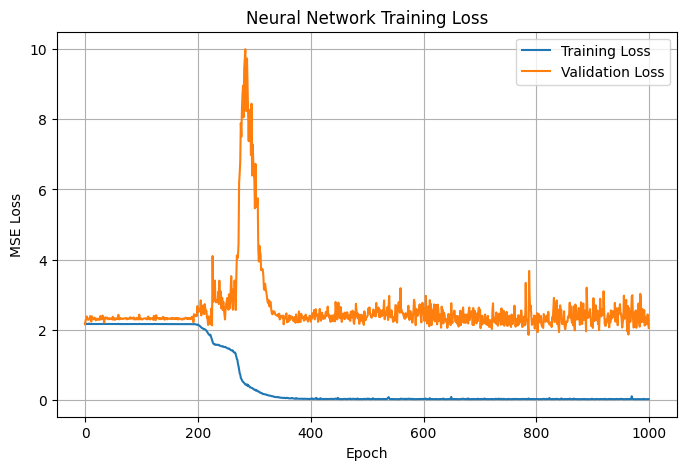

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Neural Network Training Loss")
plt.legend()
plt.grid(True)

plt.show()

In [10]:
predicted_states = model.predict(t_normalized)

print("Predicted states shape:", predicted_states.shape)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Predicted states shape: (3000, 2)


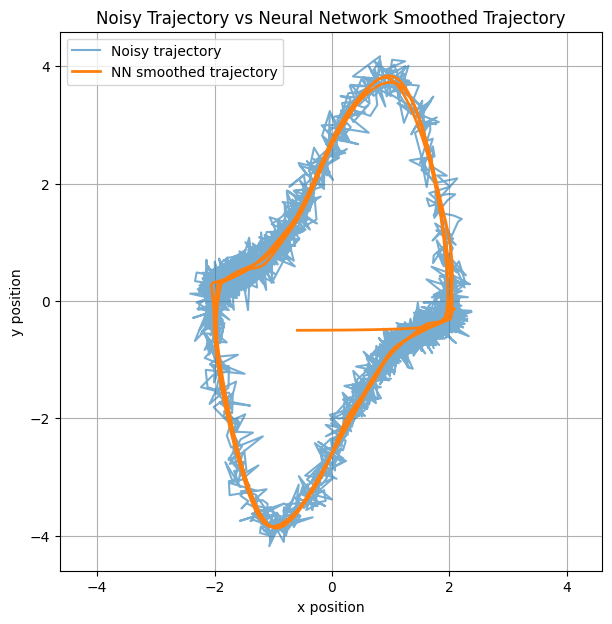

In [11]:
plt.figure(figsize=(7, 7))

plt.plot(noisy_states[:, 0], noisy_states[:, 1], label="Noisy trajectory", alpha=0.6)
plt.plot(predicted_states[:, 0], predicted_states[:, 1], label="NN smoothed trajectory", linewidth=2)

plt.xlabel("x position")
plt.ylabel("y position")
plt.title("Noisy Trajectory vs Neural Network Smoothed Trajectory")
plt.legend()
plt.grid(True)
plt.axis("equal")

plt.show()

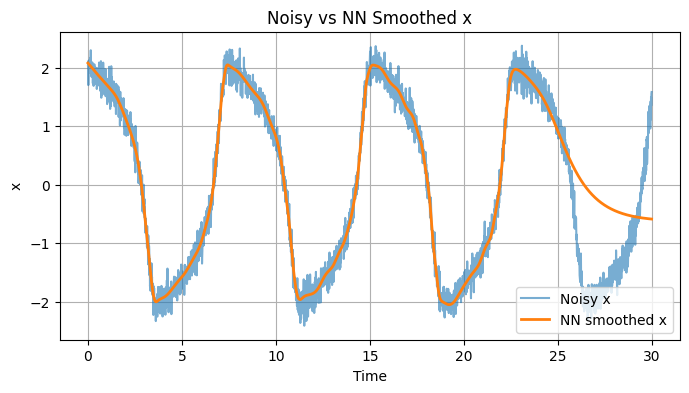

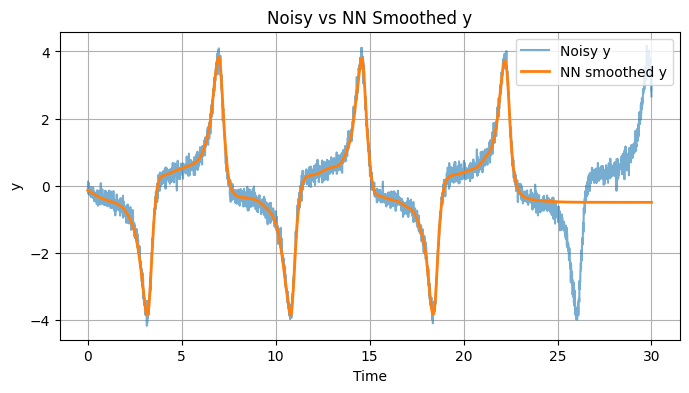

IndexError: index 2 is out of bounds for axis 1 with size 2

<Figure size 800x400 with 0 Axes>

In [12]:
state_names = ["x", "y", "theta"]

for i, name in enumerate(state_names):
    plt.figure(figsize=(8, 4))

    plt.plot(t, noisy_states[:, i], label=f"Noisy {name}", alpha=0.6)
    plt.plot(t, predicted_states[:, i], label=f"NN smoothed {name}", linewidth=2)

    plt.xlabel("Time")
    plt.ylabel(name)
    plt.title(f"Noisy vs NN Smoothed {name}")
    plt.legend()
    plt.grid(True)

    plt.show()

In [13]:
nn_rmse = np.sqrt(np.mean((noisy_states - predicted_states) ** 2))

print("Neural network reconstruction RMSE:", nn_rmse)

Neural network reconstruction RMSE: 0.6550785255504028


In [15]:
smoothed_df = pd.DataFrame({
    "t": t,
    "noisy_x": noisy_states[:, 0],
    "noisy_y": noisy_states[:, 1],
    "nn_x": predicted_states[:, 0],
    "nn_y": predicted_states[:, 1],
})

smoothed_df.head()

,t,noisy_x,noisy_y,nn_x,nn_y
0,0.000000,2.045708,-0.155998,2.084142,-0.137500
1,0.010003,2.112470,0.121667,2.080494,-0.141201
2,0.020007,1.706960,-0.233030,2.076826,-0.144914
3,0.030010,2.018327,-0.102358,2.073140,-0.148639
4,0.040013,1.996000,-0.199091,2.069436,-0.152374


In [16]:
smoothed_df.to_csv("nn_smoothed_trajectory.csv", index=False)

print("Saved: nn_smoothed_trajectory.csv")

Saved: nn_smoothed_trajectory.csv


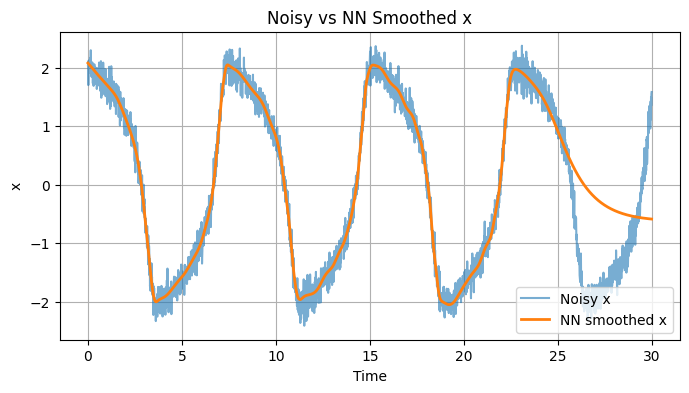

Saved: nn_smoothed_x.png


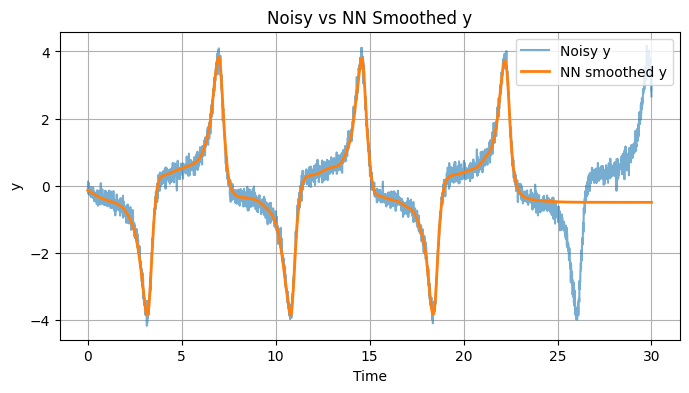

Saved: nn_smoothed_y.png


In [17]:
state_names = ["x", "y"]

for i, name in enumerate(state_names):
    plt.figure(figsize=(8, 4))

    plt.plot(t, noisy_states[:, i], label=f"Noisy {name}", alpha=0.6)
    plt.plot(t, predicted_states[:, i], label=f"NN smoothed {name}", linewidth=2)

    plt.xlabel("Time")
    plt.ylabel(name)
    plt.title(f"Noisy vs NN Smoothed {name}")
    plt.legend()
    plt.grid(True)

    filename = f"nn_smoothed_{name}.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", filename)

In [18]:
files.download("nn_smoothed_x.png")
files.download("nn_smoothed_y.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

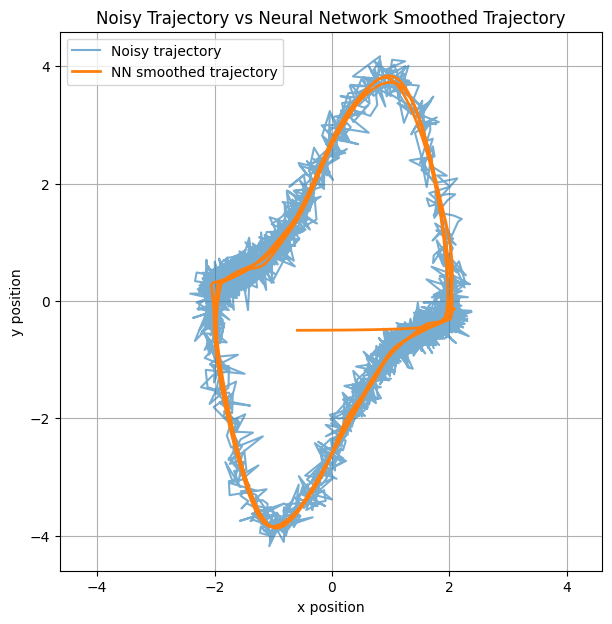

Saved: nn_smoothed_trajectory.png


In [19]:
plt.figure(figsize=(7, 7))

plt.plot(noisy_states[:, 0], noisy_states[:, 1], label="Noisy trajectory", alpha=0.6)
plt.plot(predicted_states[:, 0], predicted_states[:, 1], label="NN smoothed trajectory", linewidth=2)

plt.xlabel("x position")
plt.ylabel("y position")
plt.title("Noisy Trajectory vs Neural Network Smoothed Trajectory")
plt.legend()
plt.grid(True)
plt.axis("equal")

plt.savefig("nn_smoothed_trajectory.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: nn_smoothed_trajectory.png")

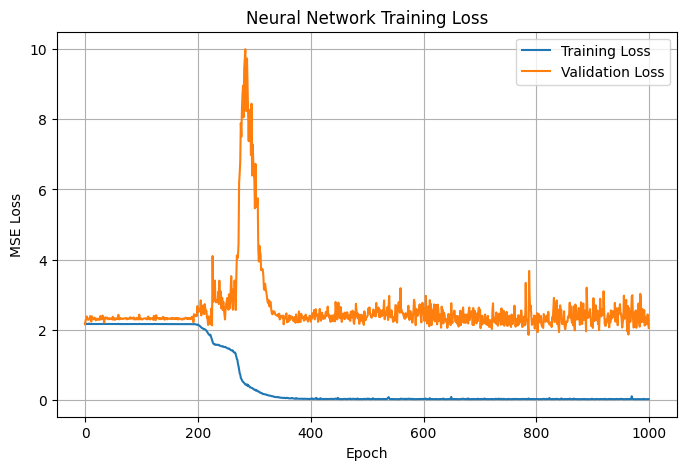

Saved: nn_training_loss.png


In [20]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Neural Network Training Loss")
plt.legend()
plt.grid(True)

plt.savefig("nn_training_loss.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: nn_training_loss.png")